<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/unsupervised/Proximity_measures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In this cell, you create a **2D matrix with random values (normally distributed)**, using numpy.random. The matrix has three columns, and we assume that each of them is the collection of objects (also called observations) related to one attribute (or predictor or feature).

In [200]:
Num_object = 20
Dim_dataset =3
X = np.random.randn(Num_object, Dim_dataset).round(2)

**Task 1:** Print the data on screen and visualize it in three different ways (image, line plot, scatterplot).

In [79]:
X.shape, X.ndim

((20, 3), 2)

In [201]:
# plot the dataset
def plot_x(X=None):
  fig, ax = plt.subplots(1, 3, figsize=(12, 4))
  # 1. line plot
  ax[0].plot(X[:, 0], label="Atribute 1")
  ax[0].legend()
  ax[0].plot(X[:, 1], label="Atribute 2")
  ax[0].legend()
  ax[0].plot(X[:, 2], label="Atribute 3")
  ax[0].set_title("Dataset line plot")
  ax[0].set_xlabel('No observation')
  ax[0].set_ylabel('Attributes')
  ax[0].legend()

  # 2. image plot
  ax[1].imshow(X, aspect="auto", label="Image")
  ax[1].set_xlabel('Attributes')
  ax[1].set_ylabel('No observation')
  ax[1].set_title("Dataset image")

  # 3. scatter plot
  ax[2].scatter(x=X[:, 0], y=X[:, 1])
  ax[2].set_title("Dataset scatter")
  ax[2].set_xlabel('Attribute 1')
  ax[2].set_ylabel('Attribute 2')

  plt.tight_layout()

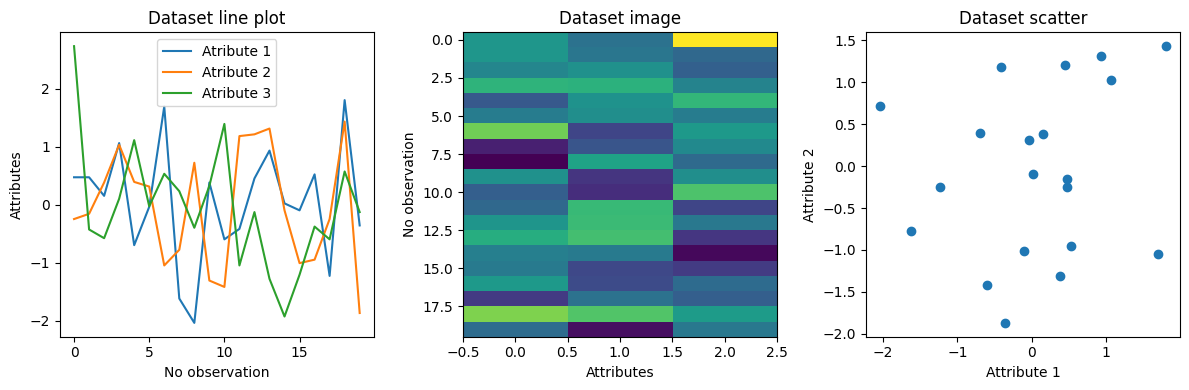

In [202]:
plot_x(X)

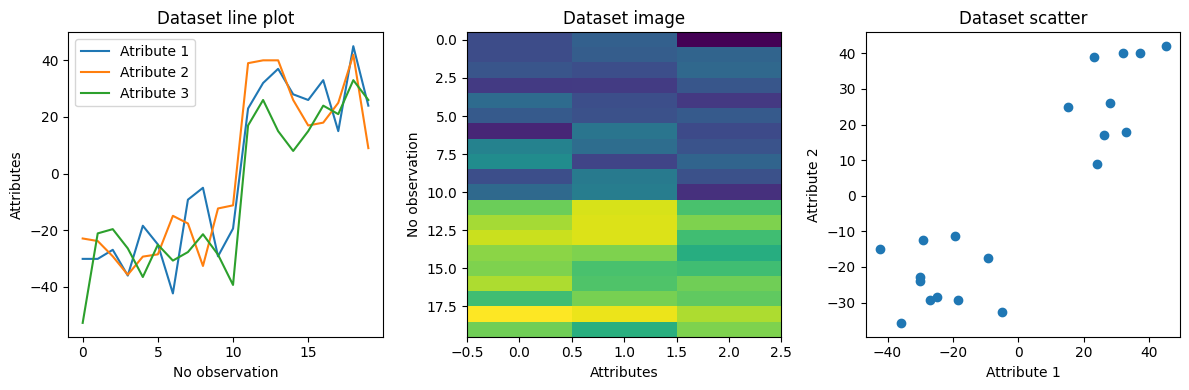

In [203]:
X = X + np.abs(X.min()) # shifting the data to make it non-negative
i = int(np.floor(Num_object/2))
# Linear Transformation(new_X = a * X + b)
X[0:i+1, :] = (X[0:i+1, :] *(-10) -5).round(2) # transforming part of X with scalling(-10(flipping))+shiftig
X[i+1:Num_object+1, :] = (X[i+1:Num_object+1, :] *10 + 7).round() # transform remaining X rows and columns(no flipping)
plot_x(X)

**Task 2:** Create a DataFrame containing the dataset, print it on the screen and visualize it using a scatterplot where labels are coded with different colors.

Use blue dots for the objects of Class 0, red dots for the objcts of Class 1, a blue square for the centroid of Class 0, and a red square for the centroid of Class 1.

In [204]:
df = pd.DataFrame(X, columns=['Attribute 1', 'Attribute 2', 'Attribute 3'])
# assigne classes to the object(first i object 0 remaining 1)
classes = [ 0 if n<i else 1 for n in range(Num_object)]
df['Class'] = classes

<Axes: xlabel='Attribute 1', ylabel='Attribute 2'>

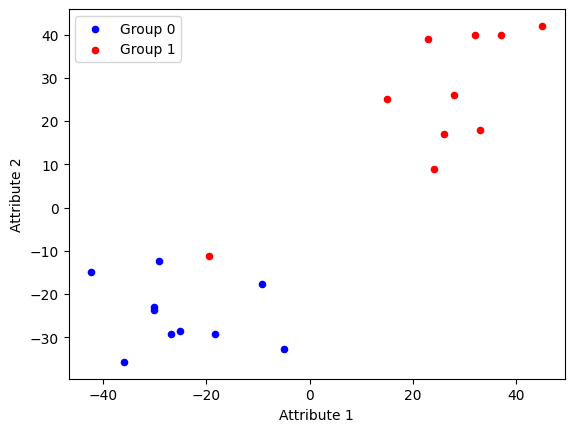

In [271]:
# plot the dataframe using scatter plot
cluster_point_0 = df.loc[df['Class']==0]
cluster_point_1 = df.loc[df['Class']==1]
ax = cluster_point_0.plot(kind='scatter', x='Attribute 1', y='Attribute 2', label="Group 0", color='blue')
cluster_point_1.plot(kind='scatter', x='Attribute 1', y='Attribute 2', label="Group 1", color='red', ax=ax, )


**Task 2a [ACTION]:** Compute the "centroid", i.e., the mean point, of each group of objects, and its coordinates.

In [256]:
K=2 # <-- number of cluster
centroidk = np.zeros(shape=(2, 3)) # 1th row belongs to cluster point 0 and 2th row for 1
centroidk[0][:] = np.array(cluster_point_0.mean()[0:3]) # Select all element of row 0 and add mean of all cluster point 0
centroidk[1][:] = np.array(cluster_point_1.mean()[0:3]) # Select all element of row 1 and add mean of all cluster point 1 to it
print(f'The centroid of cluster 0 has cordinate of {centroidk[0]}')
print(f'The centroid of cluster 1 has cordinate of {centroidk[1]}')

The centroid of cluster 0 has cordinate of [-25.22 -24.68 -28.98]
The centroid of cluster 1 has cordinate of [24.36 24.48 14.57]


In [347]:
cluster_poin_0.head(2)

,Attribute 1,Attribute 2,Attribute 3,Class
0,-30.1,-22.9,-52.7,0
1,-30.1,-23.8,-21.1,0


In [262]:
centroidk

array([[-25.22, -24.68, -28.98],
       [ 24.36,  24.48,  14.57]])

In [269]:
centroidk[0][0], centroidk[0][1]

(np.float64(-25.22), np.float64(-24.68))

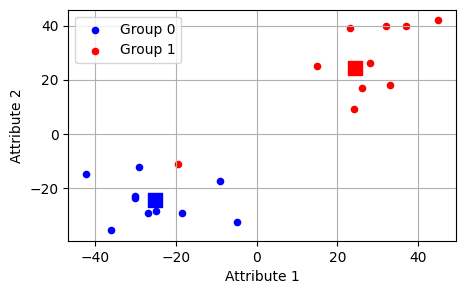

In [324]:
from matplotlib import colormaps
# plot the Centroid
ax = cluster_point_0.plot(kind='scatter', x='Attribute 1', y='Attribute 2', label="Group 0", color='blue', figsize=(5, 3))

# plot centroid of cluster 0
ax.scatter(centroidk[0][0], centroidk[0][1], label="Centroid 0", color="blue", marker='s', s=100)
# plot centroid of cluster 1
ax.scatter(centroidk[1][0], centroidk[1][1], label="Centroid 1", color="red", marker='s', s=100)

cluster_point_1.plot(kind='scatter', x='Attribute 1', y='Attribute 2', label="Group 1", color='red', ax=ax)
plt.grid()

🔑 Due to read outlier the the red centroid shifted little toward the red outlier while it could be on top right side

**Task 3:** Choose a proximity metric and compute the proximity matrix. Repeat the same for three different choices of the metric.

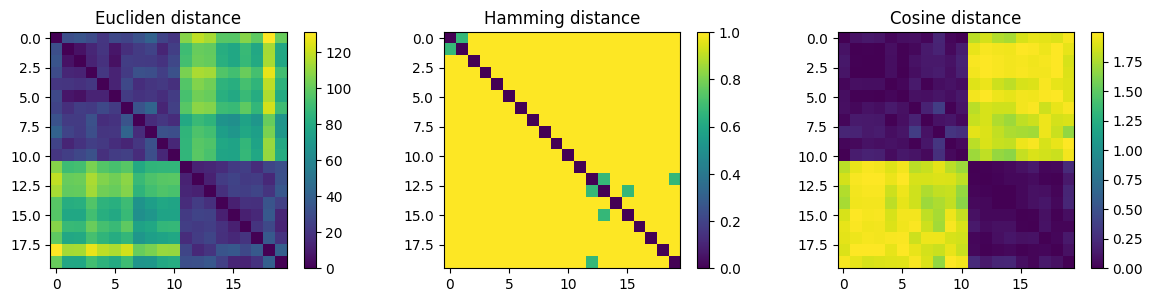

In [345]:
# Euclindean distance
euclidean_distance = sklearn.metrics.pairwise.pairwise_distances(X, metric='euclidean' )
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
eimg = ax[0].imshow(euclidean_distance)
ax[0].set_title("Eucliden distance")
fig.colorbar(eimg, ax=ax[0])

# Humming distance
hamming_distance = sklearn.metrics.pairwise.pairwise_distances(X,  metric="hamming", )
himg = ax[1].imshow(hamming_distance)
ax[1].set_title("Hamming distance")
fig.colorbar(himg, ax=ax[1])


# Cosine distance
cosine_distance = sklearn.metrics.pairwise.pairwise_distances(X,  metric="cosine")
cimg = ax[2].imshow(cosine_distance, )
ax[2].set_title("Cosine distance")
fig.colorbar(cimg, ax=ax[2])

plt.tight_layout()


In [361]:
X[:5]

array([[-30.1, -22.9, -52.7],
       [-30.1, -23.8, -21.1],
       [-26.9, -29.2, -19.6],
       [-36. , -35.7, -26.4],
       [-18.4, -29.3, -36.5]])

**Task 4:** Choose three objects (P1, P2, P3) and retrieve their pair-wise distances (P1-P2, P2-P3, P1-P3) from the three proximity matrices above (first, from euclidean_distance, then repeating the same code using PM2 and PM3).

In [376]:
# First object
p1_identifier = 3
p1 = X[p1_identifier, :]
p1_class = df['Class'][p1_identifier]
print(f'Point 1 has cordinate of {p1} belong to class {p1_class}')

# Second object
p2_identifier = 5
p2 = X[p2_identifier, :]
p2_class = df['Class'][p2_identifier]
print(f'Point 2 has cordinate of {p2} belong to class {p2_class}')

# Third object
p3_identifier = 12
p3 = X[p3_identifier, :]
p3_class = df['Class'][p3_identifier]
print(f'Point 2 has cordinate of {p3} belong to class {p3_class}')

Point 1 has cordinate of [-36.  -35.7 -26.4] belong to class 0
Point 2 has cordinate of [-25.  -28.5 -25.1] belong to class 0
Point 2 has cordinate of [32. 40. 26.] belong to class 1


In [388]:
# Calculate the distance between points
p1_p2_euc = euclidean_distance[p1_identifier][p2_identifier]
p2_p3_euc = euclidean_distance[p2_identifier][p3_identifier]
p1_p3_euc = euclidean_distance[p1_identifier][p3_identifier]
p1_p3_euc, p2_p3_euc, p1_p3_euc

(np.float64(114.45632354745631),
 np.float64(102.72516731551231),
 np.float64(114.45632354745631))

**Task 4 [ACTION]:** Fill the two tables of the slide (you can use your own notes) with the coordinates of P1, P2, and P3 as well as their distance w.r.t. the different metrics selected:

row 1: metric name   |   P1-P2   |   P2-P3   |   P1-P3

row 2: NAME          |   value   |   value   |   value

:

Make a comment on the differences you found.

In [389]:
# humming distance
p1_p2_hum = hamming_distance[p1_identifier][p2_identifier]
p2_p3_hum = hamming_distance[p2_identifier][p3_identifier]
p1_p3_hum = hamming_distance[p1_identifier][p3_identifier]
p1_p2_hum, p2_p3_hum, p1_p2_hum

(np.float64(1.0), np.float64(1.0), np.float64(1.0))

In [390]:
# Cosine distance
p1_p2_cos = cosine_distance[p1_identifier][p2_identifier]
p2_p3_cos = cosine_distance[p2_identifier][p3_identifier]
p1_p3_cos = cosine_distance[p1_identifier][p3_identifier]
p1_p2_cos, p2_p3_cos, p1_p2_cos

(np.float64(0.007266152456837371),
 np.float64(1.9926153708278067),
 np.float64(0.007266152456837371))

In [394]:
print("Metric      P1-P2    P2-P3    P1-P3")
print(f"Euclidean  {p1_p2_euc.round(2)}    {p2_p3_euc.round(2)}    {p1_p3_euc.round(2)}")
print(f"Cosine     {p1_p2_cos.round(2)}    {p2_p3_cos.round(2)}    {p1_p3_cos.round(2)}")
print(f"Humming    {p1_p2_hum.round(2)}    {p2_p3_hum.round(2)}    {p1_p3_hum.round(2)}")

Metric      P1-P2    P2-P3    P1-P3
Euclidean  13.21    102.73    114.46
Cosine     0.01    1.99    1.99
Humming    1.0    1.0    1.0


In [397]:
proximity_metrix = pd.DataFrame([
    ["Euclidean", p1_p2_euc.round(2), p2_p3_euc.round(2), p1_p3_euc.round(2)],
    ["Cosine", p1_p2_cos.round(2), p2_p3_cos.round(2), p1_p3_cos.round(2)],
    ["Humming", p1_p2_hum.round(2), p2_p3_hum.round(2), p1_p3_hum.round(2)],
    ],
                                columns=["Metric", "P1-P2", "P2-P3", "P1-P3"])

In [398]:
proximity_metrix

,Metric,P1-P2,P2-P3,P1-P3
0,Euclidean,13.21,102.73,114.46
1,Cosine,0.01,1.99,1.99
2,Humming,1.00,1.00,1.00


In [393]:
P1 = X[p1_identifier]
P2 = X[p2_identifier]
P3 = X[p3_identifier]

print("P1:", P1)
print("P2:", P2)
print("P3:", P3)

P1: [-36.  -35.7 -26.4]
P2: [-25.  -28.5 -25.1]
P3: [32. 40. 26.]
